In [16]:
import geopandas as gpd
import pandas as pd
import numpy as np
from libpysal.weights import Queen, KNN
import matplotlib.pyplot as plt
from pyprojroot import here

In [17]:
INTERIM_DATA_DIR = here() / "data" / "interim"
RESULTS_DATA_DIR = here() / "results" / "esda"
RAW_DATA_DIR = here() / "data" / "raw"

In [18]:
gdf = gpd.read_file(RAW_DATA_DIR/"geography/municipalities/00mun.shp")

print(f"Municipalities : {len(gdf)}")
print(f"CRS            : {gdf.crs.name}")
print(gdf[["CVEGEO", "CVE_ENT", "NOMGEO"]].head(5))

Municipalities : 2478
CRS            : MEXICO_ITRF_2008_LCC
  CVEGEO CVE_ENT                     NOMGEO
0  01001      01             Aguascalientes
1  01008      01         San José de Gracia
2  01011      01  San Francisco de los Romo
3  01009      01                   Tepezalá
4  01007      01            Rincón de Romos


In [19]:
w_queen = Queen.from_dataframe(gdf, silence_warnings=True)
print(f"Queen adjacencies  : {sum(len(v) for v in w_queen.neighbors.values()) // 2}")
print(f"Avg neighbors      : {w_queen.mean_neighbors:.2f}")
print(f"Islands (0 nbrs)   : {sum(1 for v in w_queen.neighbors.values() if len(v) == 0)}")

C:\Users\franc\AppData\Local\Temp\ipykernel_1032\577925112.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = Queen.from_dataframe(gdf, silence_warnings=True)


Queen adjacencies  : 6278
Avg neighbors      : 5.07
Islands (0 nbrs)   : 52


In [20]:
k = 2
w_knn = KNN.from_dataframe(gdf, k=k, silence_warnings=True)

In [21]:
queen_pairs = {
    (min(i, j), max(i, j))
    for i, nbrs in w_queen.neighbors.items()
    for j in nbrs
}
knn_pairs = {
    (min(i, j), max(i, j))
    for i, nbrs in w_knn.neighbors.items()
    for j in nbrs
}
missed_pairs = knn_pairs - queen_pairs
print(f"Queen pairs       : {len(queen_pairs)}")
print(f"KNN pairs (k={k})  : {len(knn_pairs)}")
print(f"KNN-only pairs    : {len(missed_pairs)}")

Queen pairs       : 6278
KNN pairs (k=2)  : 3324
KNN-only pairs    : 539


In [22]:
MAX_DIST_M = 5000 

missed_df = pd.DataFrame([
    {
        "idx_a"   : a,
        "idx_b"   : b,
        "cvegeo_a": gdf["CVEGEO"].iloc[a],
        "cvegeo_b": gdf["CVEGEO"].iloc[b],
        "nom_a"   : gdf["NOMGEO"].iloc[a],
        "nom_b"   : gdf["NOMGEO"].iloc[b],
        "dist_m"  : gdf.geometry.iloc[a].distance(gdf.geometry.iloc[b]),
    }
    for a, b in sorted(missed_pairs)
])

valid_missed = missed_df[missed_df["dist_m"] <= MAX_DIST_M].copy()
print(f"\nPairs within {MAX_DIST_M} m: {len(valid_missed)}")
print(valid_missed[["cvegeo_a", "nom_a", "cvegeo_b", "nom_b", "dist_m"]].to_string())


Pairs within 5000 m: 486
    cvegeo_a                              nom_a cvegeo_b                                    nom_b        dist_m
0      01001                     Aguascalientes    14035                      Encarnación de Díaz  0.000000e+00
1      01011          San Francisco de los Romo    01010                                 El Llano  3.931511e+03
2      01009                           Tepezalá    01007                          Rincón de Romos  0.000000e+00
3      01009                           Tepezalá    01004                                    Cosío  6.428145e+02
4      01009                           Tepezalá    01002                                 Asientos  0.000000e+00
6      01010                           El Llano    14064                       Ojuelos de Jalisco  0.000000e+00
7      01003                           Calvillo    32044                                  Tabasco  0.000000e+00
8      01002                           Asientos    32052                      

✓ Pairs accepted (true neighbors)  : 486
✗ Pairs rejected (false positives) : 53


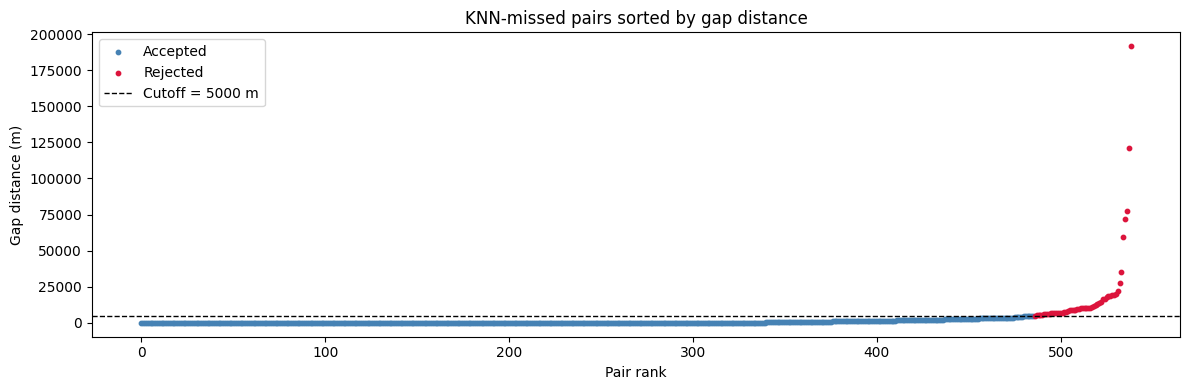


=== Rejected pairs (should be non-neighbors) ===
    cvegeo_a                       nom_a cvegeo_b                                 nom_b         dist_m
318    20032        Fresnillo de Trujano    20381            Santa Cruz Tacache de Mina    5018.424453
136    13032                    Jaltocán    30056                            Chiconamel    5205.850761
436    26013                   Banámichi    26053                   San Felipe de Jesús    5243.327291
320    20061                      Monjas    20538                   Sitio de Xitlapehua    5284.329009
75     08007                     Balleza    08033                            Huejotitán    5562.866417
89     11044                   Villagrán    11018                    Jaral del Progreso    5969.515734
52     07020                La Concordia    07117               Montecristo de Guerrero    6054.596337
492    30078                   Ixcatepec    30035                          Citlaltépetl    6266.775119
533    32013     Genera

In [23]:
MAX_DIST_M = 5000  # captures 486 true pairs, drops 53 false positives

valid_missed  = missed_df[missed_df['dist_m'] <= MAX_DIST_M].copy()
invalid_missed = missed_df[missed_df['dist_m'] >  MAX_DIST_M].copy()

print(f"✓ Pairs accepted (true neighbors)  : {len(valid_missed)}")
print(f"✗ Pairs rejected (false positives) : {len(invalid_missed)}")

# Scatter so you can spot any outlier still sneaking through
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(range(len(valid_missed)),
           valid_missed['dist_m'].sort_values().values,
           s=10, color='steelblue', label='Accepted')
ax.scatter(range(len(valid_missed), len(missed_df)),
           invalid_missed['dist_m'].sort_values().values,
           s=10, color='crimson', label='Rejected')
ax.axhline(MAX_DIST_M, color='black', linestyle='--', linewidth=1, label=f'Cutoff = {MAX_DIST_M} m')
ax.set_title("KNN-missed pairs sorted by gap distance")
ax.set_xlabel("Pair rank")
ax.set_ylabel("Gap distance (m)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DATA_DIR/"threshold_decision.png", dpi=150)
plt.show()

# Inspect the rejected pairs — confirm they are genuinely non-adjacent
print("\n=== Rejected pairs (should be non-neighbors) ===")
print(invalid_missed[["cvegeo_a", "nom_a", "cvegeo_b", "nom_b", "dist_m"]]
      .sort_values("dist_m")
      .to_string())

In [24]:
labels = gdf["CVEGEO"].tolist()     
n = len(labels)

adj_queen = pd.DataFrame(
    np.zeros((n, n), dtype=np.int8),
    index=labels, columns=labels
)
for i, nbrs in w_queen.neighbors.items():
    for j in nbrs:
        adj_queen.iloc[i, j] = 1

assert (adj_queen == adj_queen.T).all().all(), "Queen matrix not symmetric!"
print(f"Queen matrix shape : {adj_queen.shape}")

Queen matrix shape : (2478, 2478)


In [25]:
adj_combined = adj_queen.copy()

for _, row in valid_missed.iterrows():
    a, b = row["cvegeo_a"], row["cvegeo_b"]
    adj_combined.loc[a, b] = 1
    adj_combined.loc[b, a] = 1

assert (adj_combined == adj_combined.T).all().all(), "Combined matrix not symmetric!"

added = int((adj_combined.values.sum() - adj_queen.values.sum()) / 2)
print(f"Adjacencies added by KNN patch : {added}")
print(f"Total adjacencies — Queen only : {int(adj_queen.values.sum() // 2)}")
print(f"Total adjacencies — Combined   : {int(adj_combined.values.sum() // 2)}")

Adjacencies added by KNN patch : 486
Total adjacencies — Queen only : 6278
Total adjacencies — Combined   : 6764


In [26]:
# adj_queen.to_csv(INTERIM_DATA_DIR/"adj_queen.csv") # uncomment only for comparisson 
adj_combined.to_csv(INTERIM_DATA_DIR/"adj_combined.csv")
# print("Saved → adj_queen.csv")
print("Saved → adj_combined.csv")

Saved → adj_combined.csv


In [27]:
test_mun = "09015"  # change to any CVEGEO you want to inspect
if test_mun in adj_combined.index:
    nbrs = adj_combined.loc[test_mun][adj_combined.loc[test_mun] == 1].index.tolist()
    names = gdf.set_index("CVEGEO").loc[nbrs, "NOMGEO"].tolist()
    print(f"\nNeighbors of {test_mun}:")
    for c, n in zip(nbrs, names):
        print(f"  {c}  {n}")


Neighbors of 09015:
  09005  Gustavo A. Madero
  09017  Venustiano Carranza
  09014  Benito Juárez
  09006  Iztacalco
  09002  Azcapotzalco
  09016  Miguel Hidalgo


Islands in Queen    : 52
Islands in Combined : 1
Fixed by KNN patch  : 51

=== Municipalities still isolated after KNN patch ===
       CVE_ENT   NOMGEO  queen_nbrs  combined_nbrs  nearest_dist_m
CVEGEO                                                            
06009       06  Tecomán           0              0             0.0

=== Islands fixed by KNN ===
       CVE_ENT                               NOMGEO  combined_nbrs
CVEGEO                                                            
23002       23               Felipe Carrillo Puerto              2
05035       05                              Torreón              3
30104       30                            Mecayapan              3
21117       21                 Rafael Lara Grajales              2
30193       30                             Veracruz              2
12084       12                Santa Cruz del Rincón              2
04002       04                             Campeche              4
06007       06                       

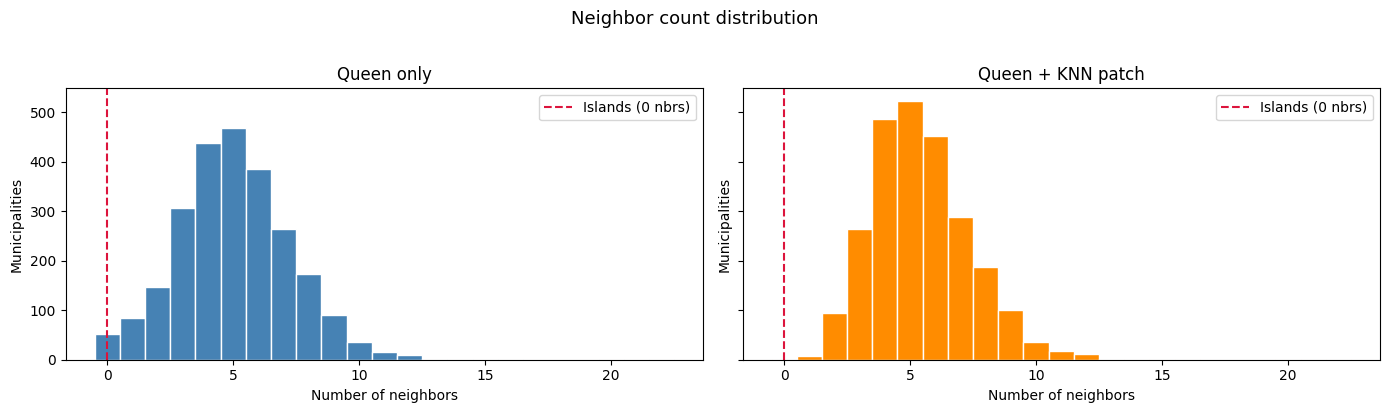

In [28]:
queen_neighbor_count = adj_queen.sum(axis=1)
combined_neighbor_count = adj_combined.sum(axis=1)

islands_queen    = queen_neighbor_count[queen_neighbor_count == 0].index.tolist()
islands_combined = combined_neighbor_count[combined_neighbor_count == 0].index.tolist()
fixed_by_knn     = set(islands_queen) - set(islands_combined)

print(f"Islands in Queen    : {len(islands_queen)}")
print(f"Islands in Combined : {len(islands_combined)}")
print(f"Fixed by KNN patch  : {len(fixed_by_knn)}")

# --- Full info table for remaining islands ---
meta = gdf.set_index("CVEGEO")[["CVE_ENT", "NOMGEO"]]

if islands_combined:
    print("\n=== Municipalities still isolated after KNN patch ===")
    island_info = meta.loc[islands_combined].copy()
    island_info["queen_nbrs"]    = queen_neighbor_count[islands_combined].values
    island_info["combined_nbrs"] = combined_neighbor_count[islands_combined].values
    # Nearest neighbor distance — how far is the closest municipality?
    island_info["nearest_dist_m"] = [
        gdf[gdf["CVEGEO"] != cvegeo].geometry.distance(
            gdf.loc[gdf["CVEGEO"] == cvegeo, "geometry"].values[0]
        ).min()
        for cvegeo in islands_combined
    ]
    print(island_info.sort_values("nearest_dist_m").to_string())
else:
    print("\n✓ No islands remain after KNN patch.")

# --- Show which islands KNN fixed ---
if fixed_by_knn:
    print("\n=== Islands fixed by KNN ===")
    fixed_info = meta.loc[list(fixed_by_knn)].copy()
    fixed_info["combined_nbrs"] = combined_neighbor_count[list(fixed_by_knn)].values
    print(fixed_info.to_string())

# --- Neighbor count distribution comparison ---
print("\n=== Neighbor count distribution ===")
stats = pd.DataFrame({
    "Queen"   : queen_neighbor_count.describe(),
    "Combined": combined_neighbor_count.describe(),
})
print(stats.round(2))

# --- Plot neighbor count histograms side by side ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, counts, title, color in zip(
    axes,
    [queen_neighbor_count, combined_neighbor_count],
    ["Queen only", "Queen + KNN patch"],
    ["steelblue", "darkorange"]
):
    ax.hist(counts, bins=range(0, int(counts.max()) + 2),
            color=color, edgecolor="white", align="left")
    ax.axvline(0, color="crimson", linestyle="--", linewidth=1.5, label="Islands (0 nbrs)")
    ax.set_title(title)
    ax.set_xlabel("Number of neighbors")
    ax.set_ylabel("Municipalities")
    ax.legend()

plt.suptitle("Neighbor count distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DATA_DIR/"neighbor_distribution.png", dpi=150)
plt.show()